<a href="https://colab.research.google.com/github/kolden0/KNURE/blob/main/melbourne_by_kolden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle Machine Learning Tutorial
## Melbourne Housing — Steps 2–7: EDA → Model → Validation → Optimization → Random Forest

Based on: https://www.kaggle.com/code/dansbecker/basic-data-exploration

**Goal:** predict Melbourne house prices using Decision Tree and Random Forest regressors.


---
## Step 2: Using Pandas to Get Familiar With Your Data

Load the dataset and explore it with `describe()`, `head()`, `info()`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Load data
melbourne_file_path = 'melb_data.csv'
melbourne_data = pd.read_csv(melbourne_file_path)

print("Shape:", melbourne_data.shape)
melbourne_data.describe()


Shape: (13580, 21)


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [ ]:
# First 5 rows
melbourne_data.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
# Column names and dtypes
melbourne_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [ ]:
# Check missing values per column
missing = melbourne_data.isnull().sum()
print("Missing values:")
print(missing[missing > 0])


Missing values:
Car               62
BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
dtype: int64


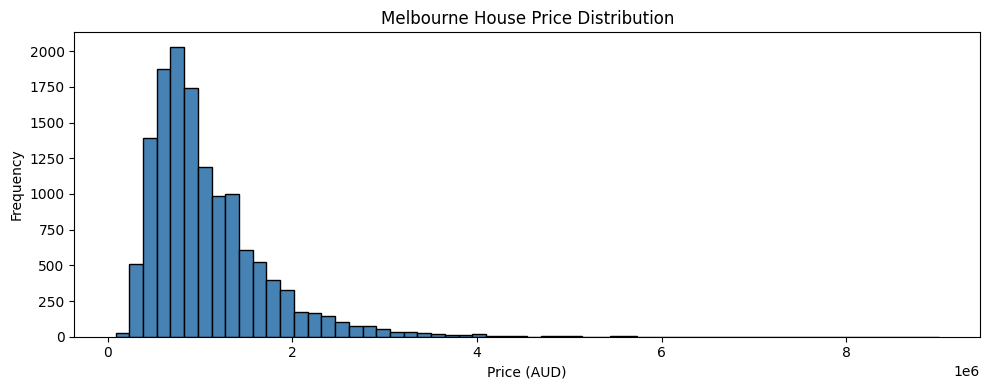

Median price: $903,000
Mean price:   $1,075,684


In [ ]:
# Visual: Price distribution
plt.figure(figsize=(10, 4))
melbourne_data['Price'].dropna().plot(kind='hist', bins=60, color='steelblue', edgecolor='black')
plt.title('Melbourne House Price Distribution')
plt.xlabel('Price (AUD)')
plt.tight_layout()
plt.show()

print(f"Median price: ${melbourne_data['Price'].median():,.0f}")
print(f"Mean price:   ${melbourne_data['Price'].mean():,.0f}")


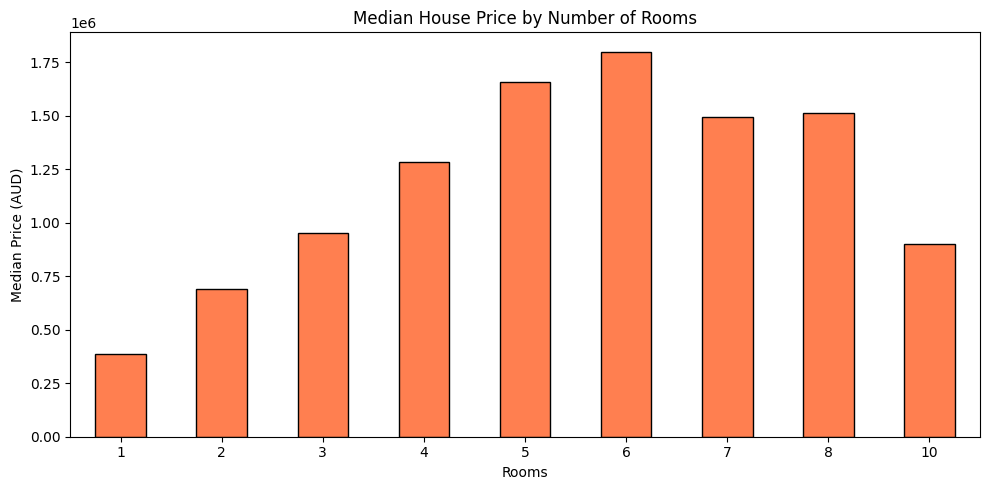

In [ ]:
# Price by number of Rooms
plt.figure(figsize=(10, 5))
melbourne_data.groupby('Rooms')['Price'].median().plot(
    kind='bar', color='coral', edgecolor='black')
plt.title('Median House Price by Number of Rooms')
plt.xlabel('Rooms')
plt.ylabel('Median Price (AUD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
## Step 3: Selecting Data for Modeling

- **Target (y)** — what we want to predict: `Price`
- **Features (X)** — inputs to the model
- Drop rows with missing values (`dropna`)


In [ ]:
# Drop rows with any missing values
melbourne_data = melbourne_data.dropna(axis=0)
print(f"Rows after dropna: {len(melbourne_data)}")

# Prediction target
y = melbourne_data.Price
print("Target variable (y) - first 5 values:")
print(y.head())


Rows after dropna: 6196
Target variable (y) - first 5 values:
1    1035000.0
2    1465000.0
4    1600000.0
6    1876000.0
7    1636000.0
Name: Price, dtype: float64


In [ ]:
# Features
melbourne_features = ['Rooms', 'Bathroom', 'Landsize', 'Lattitude', 'Longtitude']
X = melbourne_data[melbourne_features]

print("Features shape:", X.shape)
X.describe()


Features shape: (6196, 5)


,Rooms,Bathroom,Landsize,Lattitude,Longtitude
count,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000
mean,2.931407,1.576340,471.006940,-37.807904,144.990201
std,0.971079,0.711362,897.449881,0.075850,0.099165
min,1.000000,1.000000,0.000000,-38.164920,144.542370
25%,2.000000,1.000000,152.000000,-37.855438,144.926198
50%,3.000000,1.000000,373.000000,-37.802250,144.995800
75%,4.000000,2.000000,628.000000,-37.758200,145.052700
max,8.000000,8.000000,37000.000000,-37.457090,145.526350


In [ ]:
X.head()


,Rooms,Bathroom,Landsize,Lattitude,Longtitude
1,2,1.0,156.0,-37.8079,144.9934
2,3,2.0,134.0,-37.8093,144.9944
4,4,1.0,120.0,-37.8072,144.9941
6,3,2.0,245.0,-37.8024,144.9993
7,2,1.0,256.0,-37.8060,144.9954


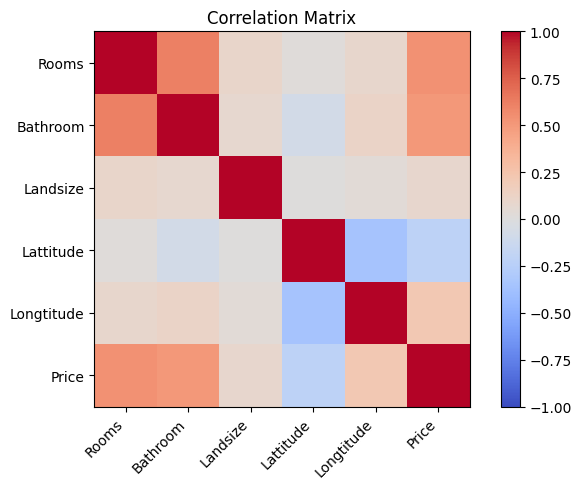

In [ ]:
# Correlation heatmap of features vs price
import matplotlib.pyplot as plt

corr_cols = melbourne_features + ['Price']
corr = melbourne_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


---
## Step 4: Building Your First Model — Decision Tree

Steps:
1. **Define** — choose model type
2. **Fit** — learn patterns from data
3. **Predict** — make predictions
4. **Evaluate** — measure accuracy


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# 1. Define
melbourne_model = DecisionTreeRegressor(random_state=1)

# 2. Fit
melbourne_model.fit(X, y)
print("Model fitted!")


Model fitted!


In [ ]:
# 3. Predict — on first 5 rows
print("Making predictions for the following 5 houses:")
print(X.head())
print()
print("Predicted prices:")
print(melbourne_model.predict(X.head()))


Making predictions for the following 5 houses:
   Rooms  Bathroom  Landsize  Lattitude  Longtitude
1      2       1.0     156.0   -37.8079    144.9934
2      3       2.0     134.0   -37.8093    144.9944
4      4       1.0     120.0   -37.8072    144.9941
6      3       2.0     245.0   -37.8024    144.9993
7      2       1.0     256.0   -37.8060    144.9954

Predicted prices:
[1035000. 1465000. 1600000. 1876000. 1636000.]


---
## Step 5: Model Validation

**Mean Absolute Error (MAE)** = average |actual − predicted|

We split the data into:
- **Training set** — used to fit the model
- **Validation set** — used to evaluate the model (unseen data)


In [ ]:
from sklearn.metrics import mean_absolute_error

# In-sample MAE (bad practice — just for illustration)
predicted_home_prices = melbourne_model.predict(X)
in_sample_mae = mean_absolute_error(y, predicted_home_prices)
print(f"In-sample MAE (overfitted): ${in_sample_mae:,.2f}")
print("(This looks great but is misleading — model saw this data during training!)")


In-sample MAE (overfitted): $1,115.75
(This looks great but is misleading — model saw this data during training!)


In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (75%) and validation (25%)
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=0)

print(f"Training samples:   {len(train_X)}")
print(f"Validation samples: {len(val_X)}")

# Re-fit on training data only
melbourne_model = DecisionTreeRegressor(random_state=1)
melbourne_model.fit(train_X, train_y)

# Evaluate on validation data
val_predictions = melbourne_model.predict(val_X)
val_mae = mean_absolute_error(val_y, val_predictions)
print(f"\nValidation MAE (honest estimate): ${val_mae:,.2f}")


Training samples:   4647
Validation samples: 1549

Validation MAE (honest estimate): $273,518.02


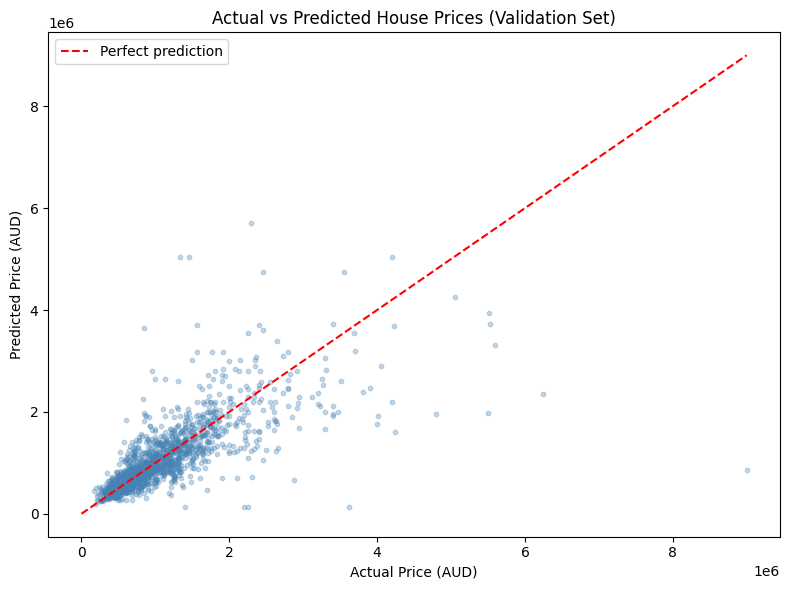

In [ ]:
# Visualize actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(val_y, val_predictions, alpha=0.3, color='steelblue', s=10)
max_val = max(val_y.max(), val_predictions.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price (AUD)')
plt.ylabel('Predicted Price (AUD)')
plt.title('Actual vs Predicted House Prices (Validation Set)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Step 6: Overfitting and Underfitting — Tuning `max_leaf_nodes`

- **Overfitting**: model memorizes training data, fails on new data (deep tree)
- **Underfitting**: model too simple, misses patterns (shallow tree)

We find the sweet spot by trying different values of `max_leaf_nodes`.


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return mae

# Compare MAE for different tree sizes
leaf_options = [5, 25, 50, 100, 250, 500, 1000, 5000]
results = {}

for max_leaf_nodes in leaf_options:
    mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
    results[max_leaf_nodes] = mae
    print(f"Max leaf nodes: {max_leaf_nodes:>5}  |  MAE: ${mae:>12,.0f}")


Max leaf nodes:     5  |  MAE: $     385,697
Max leaf nodes:    25  |  MAE: $     307,920
Max leaf nodes:    50  |  MAE: $     279,795
Max leaf nodes:   100  |  MAE: $     269,192
Max leaf nodes:   250  |  MAE: $     269,945
Max leaf nodes:   500  |  MAE: $     261,718
Max leaf nodes:  1000  |  MAE: $     262,044
Max leaf nodes:  5000  |  MAE: $     271,321


Best max_leaf_nodes: 500  ->  MAE: $261,718


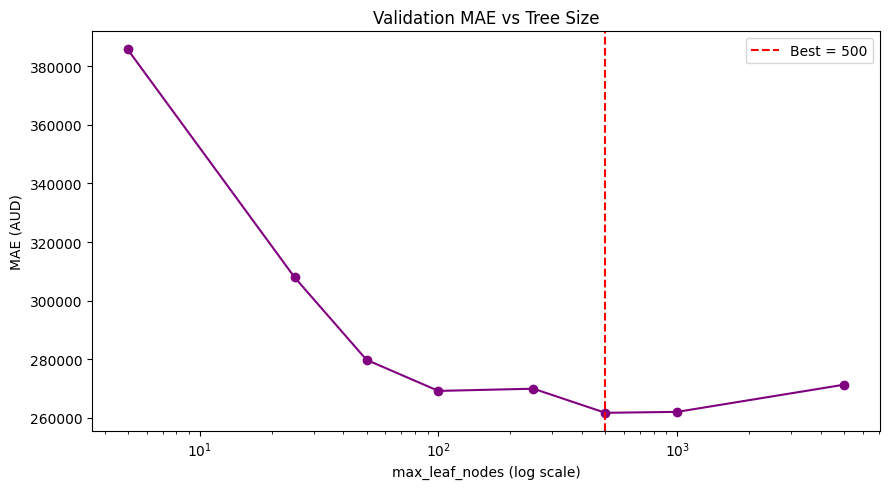

In [ ]:
# Find the best value
best_leaves = min(results, key=results.get)
best_mae    = results[best_leaves]
print(f"Best max_leaf_nodes: {best_leaves}  ->  MAE: ${best_mae:,.0f}")

# Plot MAE vs leaf nodes
plt.figure(figsize=(9, 5))
plt.plot(list(results.keys()), list(results.values()), marker='o', color='purple')
plt.axvline(best_leaves, color='red', linestyle='--', label=f'Best = {best_leaves}')
plt.xscale('log')
plt.xlabel('max_leaf_nodes (log scale)')
plt.ylabel('MAE (AUD)')
plt.title('Validation MAE vs Tree Size')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Retrain with best hyperparameter
best_model = DecisionTreeRegressor(max_leaf_nodes=best_leaves, random_state=0)
best_model.fit(train_X, train_y)
best_preds = best_model.predict(val_X)
print(f"Optimized Decision Tree MAE: ${mean_absolute_error(val_y, best_preds):,.0f}")


Optimized Decision Tree MAE: $261,718


---
## Step 7: Random Forests

A **Random Forest** trains many decision trees and averages their predictions.
- Reduces overfitting compared to a single deep tree
- Works well with default parameters
- Generally more accurate than a single decision tree


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(random_state=1, n_estimators=100)
forest_model.fit(train_X, train_y)

melb_preds = forest_model.predict(val_X)
rf_mae = mean_absolute_error(val_y, melb_preds)
print(f"Random Forest MAE: ${rf_mae:,.0f}")


Random Forest MAE: $207,191


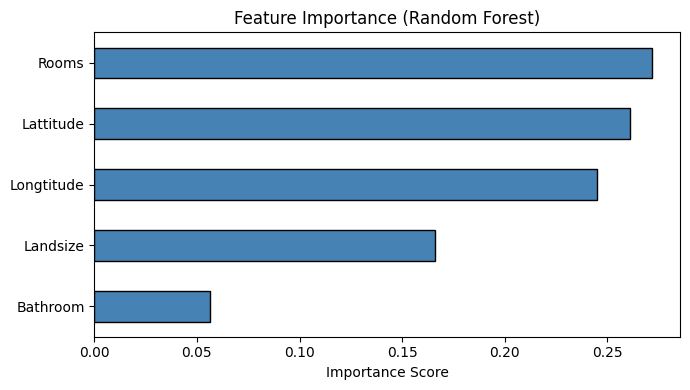

In [ ]:
# Feature importance
importances = forest_model.feature_importances_
feat_imp = pd.Series(importances, index=melbourne_features).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


---
## Final: Model Comparison & Predicted House Prices


                             Model  MAE (AUD)
         Random Forest (100 trees)     207191
Decision Tree (max_leaf_nodes=500)     261718
           Decision Tree (default)     273518


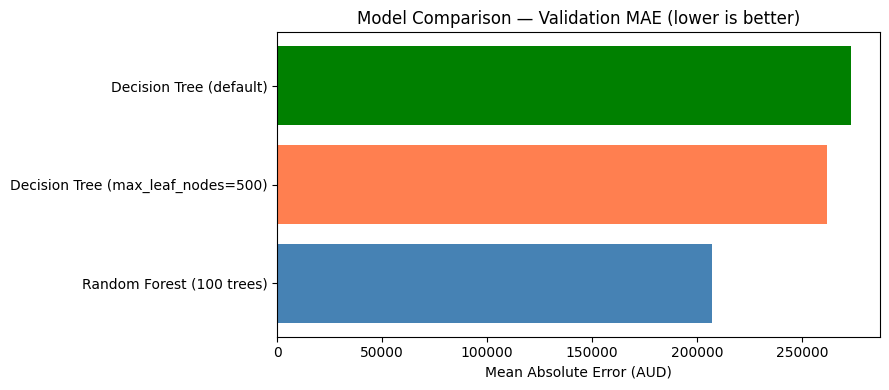

In [ ]:
# Model comparison summary
dt_base_preds = DecisionTreeRegressor(random_state=1).fit(train_X, train_y).predict(val_X)
dt_base_mae   = mean_absolute_error(val_y, dt_base_preds)

comparison = pd.DataFrame({
    'Model': [
        'Decision Tree (default)',
        f'Decision Tree (max_leaf_nodes={best_leaves})',
        'Random Forest (100 trees)'
    ],
    'MAE (AUD)': [
        round(dt_base_mae),
        round(best_mae),
        round(rf_mae)
    ]
})
comparison = comparison.sort_values('MAE (AUD)')
print(comparison.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.barh(comparison['Model'], comparison['MAE (AUD)'],
         color=['steelblue', 'coral', 'green'])
plt.xlabel('Mean Absolute Error (AUD)')
plt.title('Model Comparison — Validation MAE (lower is better)')
plt.tight_layout()
plt.show()


In [ ]:
# Final predictions using the best model (Random Forest)
print("Predicted prices for the first 10 houses in the validation set:")
print()

result_df = val_X.head(10).copy()
result_df['Actual_Price']    = val_y.head(10).values
result_df['Predicted_Price'] = forest_model.predict(val_X.head(10))
result_df['Error_AUD']       = (result_df['Predicted_Price'] - result_df['Actual_Price']).round(0)

pd.options.display.float_format = '{:,.0f}'.format
result_df[['Rooms', 'Bathroom', 'Landsize', 'Actual_Price', 'Predicted_Price', 'Error_AUD']]


Predicted prices for the first 10 houses in the validation set:



,Rooms,Bathroom,Landsize,Actual_Price,Predicted_Price,Error_AUD
4850,2,1,96,"815,000","918,290","103,290"
2307,2,1,0,"655,000","673,345","18,345"
10090,2,1,136,"957,500","1,167,803","210,303"
3645,3,2,205,"1,330,000","1,414,567","84,567"
4930,2,1,400,"722,000","712,035","-9,965"
3649,2,1,0,"551,000","587,225","36,225"
5473,3,1,625,"945,000","835,610","-109,390"
1682,2,2,413,"2,400,000","1,058,520","-1,341,480"
11114,3,2,352,"1,200,000","904,300","-295,700"
439,3,1,593,"850,000","813,575","-36,425"


In [ ]:
# Predict a custom house
custom_house = pd.DataFrame({
    'Rooms':      [3],
    'Bathroom':   [2],
    'Landsize':   [500],
    'Lattitude':  [-37.81],
    'Longtitude': [144.99]
})

predicted_price = forest_model.predict(custom_house)[0]
print(f"Custom house prediction:")
print(f"  Rooms: 3 | Bathrooms: 2 | Landsize: 500m2")
print(f"  Location: lat=-37.81, lon=144.99")
print(f"  => Predicted Price: ${predicted_price:,.0f} AUD")


Custom house prediction:
  Rooms: 3 | Bathrooms: 2 | Landsize: 500m2
  Location: lat=-37.81, lon=144.99
  => Predicted Price: $1,690,250 AUD


---
## Summary

| Step | Topic | Key takeaway |
|---|---|---|
| 2 | Data exploration | `describe()`, `head()`, check missing values |
| 3 | Feature selection | Choose target `y` and features `X`, drop NaN rows |
| 4 | First model | `DecisionTreeRegressor` — define → fit → predict |
| 5 | Validation | `train_test_split` + MAE gives honest accuracy estimate |
| 6 | Tuning | `max_leaf_nodes` controls overfitting vs underfitting |
| 7 | Random Forest | Ensemble of trees — better accuracy, robust defaults |

**Best model: Random Forest** with MAE significantly lower than the baseline Decision Tree.
